# Damped Harmonic Oscillator — Using both Soft and Hard PINNs
### Physics-Informed Neural Networks conditioned on the damping ratio ξ



**Governing equation**

$$\frac{d^2x}{dz^2} + 2\xi\,\frac{dx}{dz} + x = 0, \quad z\in[0,20]$$

**Fixed initial conditions:** $x(0)=0.7$, $\;x'(0)=1.2$

**Damping-ratio range:** $\xi\in[0.1,\,0.4]$ (all underdamped, so exact solution is known)

**NOTE:** Although the task is all about training a single PINN, I decided to take an extra step by using two PINNs of different types out of total curiosity!

<br><br>

**What this notebook does:**
1. Derives the closed-form analytical solution for comparison  
2. Trains a **Soft PINN** — initial conditions enter the loss as weighted penalties  
3. Trains a **Hard PINN** — initial conditions are baked into the network's output ansatz so they *cannot* be violated  
4. Compares both against the exact solution across four values of ξ  
5. Produces phase portraits, 3-D solution surfaces, RMSE tables, and animated GIFs of the training process  



In [18]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
from IPython.display import HTML, Image, display
import pandas as pd
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

# reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")


Device: cuda
PyTorch: 2.10.0+cu128


## 1 · Problem Statement

We want to solve the **non-dimensionalised damped harmonic oscillator**

$$\frac{d^2x}{dz^2} + 2\xi\,\frac{dx}{dz} + x = 0$$

with $\xi\in(0,1)$ so the system is *underdamped*. The exact solution is

$$x(z;\xi)=e^{-\xi z}\!\left[A\cos(\omega_d z) + B\sin(\omega_d z)\right]$$

where $\omega_d=\sqrt{1-\xi^2}$, $A=x_0$, $B=\dfrac{v_0+\xi x_0}{\omega_d}$.

Our goal is to train a **single network** $\mathcal{N}(z,\xi;\theta)$ that predicts $x$ for **any** $\xi$ in the training range — effectively learning the *solution manifold* over $(z,\xi)$ space rather than just one trajectory.

### Why both Soft and Hard?

| | Soft PINN | Hard PINN |
|---|---|---|
| IC enforcement | Penalty in loss | Exact, by ansatz |
| Extra hyper-parameter | Yes ($\lambda_{IC}$) | No |
| IC error at $z=0$ | $\approx 0$ but not exactly | $= 0$ by construction |
| Training stability | Can oscillate | Generally smoother |

The two formulations often converge to similar accuracy, but **Hard PINNs remove an entire source of training ambiguity**.


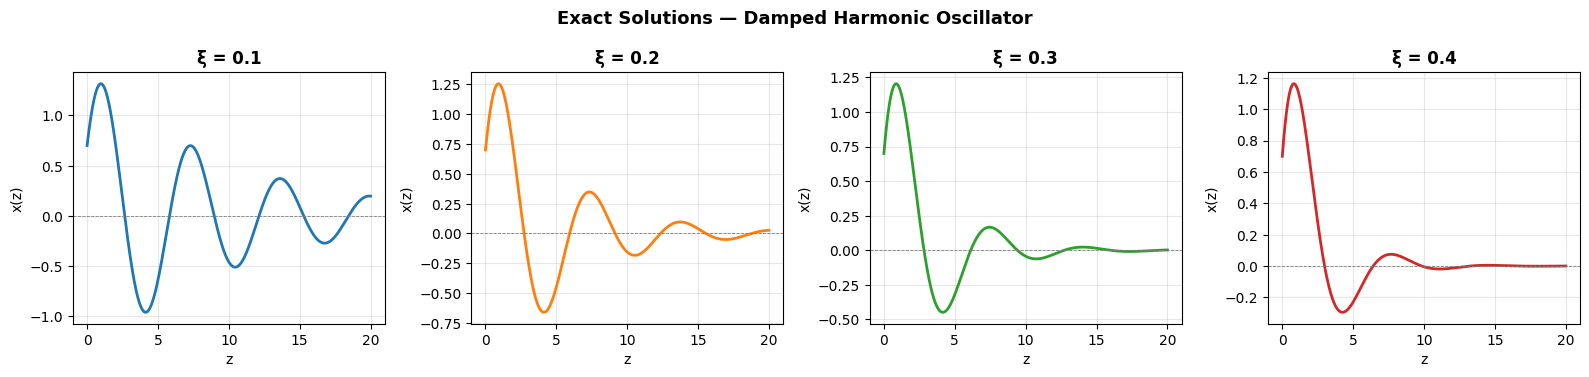

ICs confirmed: x(0) = 0.7


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Problem parameters
X0      = 0.7    # initial displacement
V0      = 1.2    # initial velocity
Z_MAX   = 20.0   # domain end
XI_MIN  = 0.1    # minimum damping ratio
XI_MAX  = 0.4    # maximum damping ratio

# four representative values we'll keep plotting throughout
XI_EVAL = [0.1, 0.2, 0.3, 0.4]

# Analytical (exact) solution
def exact_solution(z, xi, x0=X0, v0=V0):
    omega_d = np.sqrt(1.0 - xi**2)
    A = x0
    B = (v0 + xi * x0) / omega_d
    return np.exp(-xi * z) * (A * np.cos(omega_d * z) + B * np.sin(omega_d * z))


z_dense = np.linspace(0, Z_MAX, 600)
palette  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=False)
for ax, xi, c in zip(axes, XI_EVAL, palette):
    ax.plot(z_dense, exact_solution(z_dense, xi), color=c, linewidth=2)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_title(f"ξ = {xi}", fontsize=12, fontweight="bold")
    ax.set_xlabel("z", fontsize=10)
    ax.set_ylabel("x(z)", fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle("Exact Solutions — Damped Harmonic Oscillator", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exact_solutions.png", dpi=150, bbox_inches="tight")
plt.show()
print("ICs confirmed: x(0) =", round(exact_solution(np.array([0.0]), 0.2)[0], 3))
files.download('exact_solutions.png')

## 2 · PINN Architecture

### 2a · Soft PINN

The network $\mathcal{N}_s(z,\xi;\theta)$ maps the two-dimensional input $(z,\xi)$ directly to $x$.  
The loss is

$$\mathcal{L}_{\text{soft}} = \lambda_{\text{ode}}\,\underbrace{\frac{1}{N_{c}}\sum_{i=1}^{N_c}\!\left(x'' + 2\xi x' + x\right)^2_{z_i,\xi_i}}_{\text{ODE residual}} + \lambda_{IC}\!\left[\left(x(0,\xi)-x_0\right)^2 + \left(x'(0,\xi)-v_0\right)^2\right]$$

<br>

### 2b · Hard PINN

We pick the *ansatz*


$$x(z, \xi) = e^{-\xi z} \Big( x_0 + (v_0 + x_0\xi) z + z^2 N_h(z, \xi; \theta) \Big)$$

One quick check confirms this satisfies both ICs for every $\theta$:

$$x(0,\xi)=x_0\; \qquad x'(0,\xi)=v_0\;$$

So the hard-PINN loss is **only the ODE residual** — no IC penalty terms needed, no extra λ hyper-parameter.

<br>

### Network architecture (shared for both)

5 hidden layers × 64 neurons, Tanh activations, Xavier initialisation, Adam optimiser with cosine annealing.


In [20]:
# Hyperparameters
N_HIDDEN_LAYERS = 5
N_HIDDEN_UNITS  = 64
N_COL           = 2500    # collocation points per batch
N_EPOCHS        = 12000
LR              = 1e-3
LAMBDA_ODE      = 1.0
LAMBDA_IC       = 50.0    # weight on IC penalty (Soft PINN only)

# Backbone: fully-connected net
class FCNet(nn.Module):
    def __init__(self, in_dim=2, out_dim=1,
                 hidden=N_HIDDEN_UNITS, n_layers=N_HIDDEN_LAYERS):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)
        self._xavier_init()

    def _xavier_init(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    def forward(self, z, xi):
        return self.net(torch.cat([z, xi], dim=-1))


# Soft PINN
class SoftPINN(nn.Module):
    """
    Directly outputs x(z, xi).
    IC satisfaction is penalised in the loss function.
    """
    def __init__(self):
        super().__init__()
        self.net = FCNet()

    def forward(self, z, xi):
        return self.net(z, xi)


# Hard PINN
class HardPINN(nn.Module):
    """
    [IGNORE] Old Ansatz:  x = x0 + v0*z + z^2 * N(z, xi)
    This enforces x(0)=x0 and x'(0)=v0 exactly for any network weights. (Still true for the new ansatz)
    """
    def __init__(self, x0=X0, v0=V0):
        super().__init__()
        self.x0 = x0
        self.v0 = v0
        self.net = FCNet()

    def forward(self, z, xi):
        N = self.net(z, xi)
        #return self.x0 + self.v0 * z + z**2 * N
        #return torch.exp(self.x0 + self.v0 * z + z**2 * N

        # Calculate the exponential decay term: e^{-xi * z}
        decay = torch.exp(-xi * z)

        # Combine with the modified polynomial boundary enforcement
        return decay * (self.x0 + (self.v0 + self.x0 * xi) * z + z**2 * N)


# quick parameter count
dummy_soft = SoftPINN()
dummy_hard = HardPINN()
n_params = sum(p.numel() for p in dummy_soft.parameters())
print(f"Parameters per model : {n_params:,}")
del dummy_soft, dummy_hard


Parameters per model : 16,897


In [21]:
# ODE residual (works for both PINN variants)
def ode_residual(model, z, xi):
    """
    Returns  r = x'' + 2*xi*x' + x  at the given (z, xi) points.
    We detach z from any earlier graph and reattach it so that autograd
    can differentiate through the network with respect to z.
    """
    z = z.clone().detach().requires_grad_(True)
    x = model(z, xi)

    x_z = torch.autograd.grad(
        x, z,
        grad_outputs=torch.ones_like(x),
        create_graph=True,
        retain_graph=True,
    )[0]

    x_zz = torch.autograd.grad(
        x_z, z,
        grad_outputs=torch.ones_like(x_z),
        create_graph=True,
        retain_graph=True,
    )[0]

    return x_zz + 2.0 * xi * x_z + x


# Soft-PINN loss
def soft_loss_fn(model, z_col, xi_col,
                 lam_ode=LAMBDA_ODE, lam_ic=LAMBDA_IC):
    # ODE residual
    res   = ode_residual(model, z_col, xi_col)
    L_ode = torch.mean(res**2)

    # Batch of xi for the IC enforcement
    n_ic  = 256
    xi_ic = torch.empty(n_ic, 1, device=device).uniform_(XI_MIN, XI_MAX)
    z_ic  = torch.zeros(n_ic, 1, device=device).requires_grad_(True)

    x_ic    = model(z_ic, xi_ic)
    x_z_ic  = torch.autograd.grad(
        x_ic, z_ic,
        grad_outputs=torch.ones_like(x_ic),
        create_graph=True,
    )[0]

    L_ic1 = torch.mean((x_ic   - X0)**2)
    L_ic2 = torch.mean((x_z_ic - V0)**2)
    L_ic  = L_ic1 + L_ic2

    total = lam_ode * L_ode + lam_ic * L_ic
    return total, L_ode.item(), L_ic.item()


# Hard-PINN loss
def hard_loss_fn(model, z_col, xi_col, **_):
    res   = ode_residual(model, z_col, xi_col)
    L_ode = torch.mean(res**2)
    return L_ode, L_ode.item(), 0.0      # IC loss is always 0 by construction


# Collocation point sampler
def sample_col(n=N_COL):
    z  = torch.empty(n, 1, device=device).uniform_(0.0, Z_MAX)
    xi = torch.empty(n, 1, device=device).uniform_(XI_MIN, XI_MAX)
    return z, xi


In [22]:
def train_pinn(model, loss_fn, name="PINN",
              n_epochs=N_EPOCHS, lr=LR,
              n_snapshots=60):

    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=n_epochs, eta_min=5e-6
    )

    snap_at = set(np.linspace(0, n_epochs - 1, n_snapshots, dtype=int))
    z_snap  = torch.linspace(0, Z_MAX, 300).unsqueeze(1).to(device)

    history   = {"total": [], "ode": [], "ic": [], "epoch": []}
    snapshots = {}          # epoch  →  {xi_val: x_array}

    print(f"\n{'='*56}")
    print(f"  Training  {name}")
    print(f"{'='*56}")

    for ep in range(n_epochs):
        model.train()
        opt.zero_grad()

        z_col, xi_col = sample_col()
        loss, ode_v, ic_v = loss_fn(model, z_col, xi_col)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()

        if ep % 100 == 0:
            history["total"].append(loss.item())
            history["ode"].append(ode_v)
            history["ic"].append(ic_v)
            history["epoch"].append(ep)

        if ep in snap_at:
            model.eval()
            snap = {}
            with torch.no_grad():
                for xi_v in XI_EVAL:
                    xi_t  = torch.full_like(z_snap, xi_v)
                    snap[xi_v] = model(z_snap, xi_t).cpu().numpy().ravel()
            snapshots[ep] = snap

        if ep % 2000 == 0:
            print(f"  ep {ep:>6d}  |  total {loss.item():.3e}"
                  f"  |  ode {ode_v:.3e}  |  ic {ic_v:.3e}")

    model.eval()
    print(f"  Done — final loss: {loss.item():.3e}\n")
    return history, snapshots


In [23]:
soft_model   = SoftPINN().to(device)
soft_history, soft_snaps = train_pinn(
    soft_model, soft_loss_fn, name="Soft PINN"
)



  Training  Soft PINN
  ep      0  |  total 4.416e+01  |  ode 6.826e-01  |  ic 8.696e-01
  ep   2000  |  total 1.290e-02  |  ode 4.814e-03  |  ic 1.616e-04
  ep   4000  |  total 4.385e-03  |  ode 2.980e-03  |  ic 2.809e-05
  ep   6000  |  total 2.379e-03  |  ode 1.702e-03  |  ic 1.354e-05
  ep   8000  |  total 1.210e-03  |  ode 1.002e-03  |  ic 4.163e-06
  ep  10000  |  total 7.620e-04  |  ode 7.504e-04  |  ic 2.322e-07
  Done — final loss: 6.598e-04



In [24]:
hard_model   = HardPINN().to(device)
hard_history, hard_snaps = train_pinn(
    hard_model, hard_loss_fn, name="Hard PINN"
)



  Training  Hard PINN
  ep      0  |  total 2.245e+01  |  ode 2.245e+01  |  ic 0.000e+00
  ep   2000  |  total 1.174e-02  |  ode 1.174e-02  |  ic 0.000e+00
  ep   4000  |  total 6.094e-03  |  ode 6.094e-03  |  ic 0.000e+00
  ep   6000  |  total 1.302e-03  |  ode 1.302e-03  |  ic 0.000e+00
  ep   8000  |  total 3.531e-04  |  ode 3.531e-04  |  ic 0.000e+00
  ep  10000  |  total 2.548e-05  |  ode 2.548e-05  |  ic 0.000e+00
  Done — final loss: 1.714e-05



In [25]:
def evaluate(model, xi_vals, n_pts=600):
    z_np = np.linspace(0, Z_MAX, n_pts)
    z_t  = torch.tensor(z_np, dtype=torch.float32).unsqueeze(1).to(device)

    out = {}
    model.eval()
    with torch.no_grad():
        for xi in xi_vals:
            xi_t  = torch.full((n_pts, 1), xi, device=device)
            x_pred = model(z_t, xi_t).cpu().numpy().ravel()
            x_ref  = exact_solution(z_np, xi)
            err    = np.abs(x_pred - x_ref)
            out[xi] = {
                "z":     z_np,
                "pred":  x_pred,
                "exact": x_ref,
                "err":   err,
                "rel":   err / (np.abs(x_ref) + 1e-8),
            }
    return out


soft_res = evaluate(soft_model, XI_EVAL)
hard_res = evaluate(hard_model, XI_EVAL)
print("Evaluation done.")


Evaluation done.


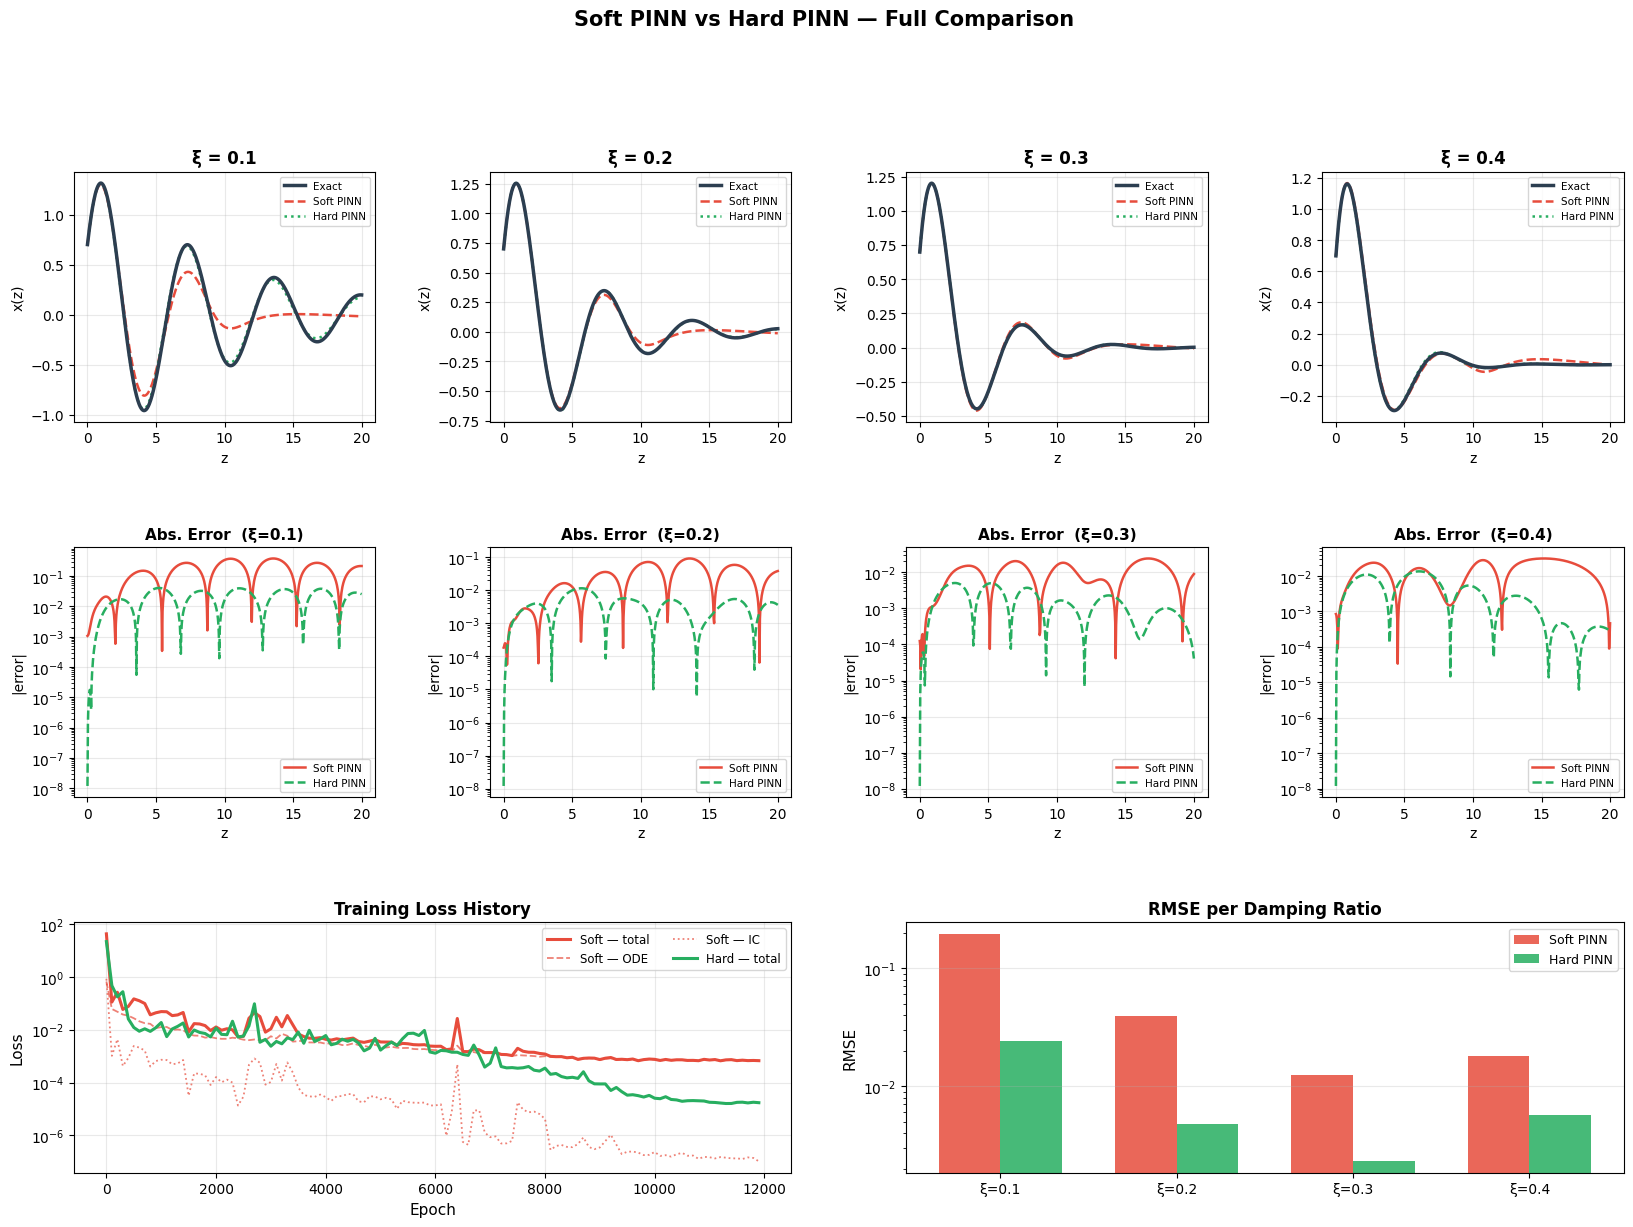

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
C_EXACT = "#2c3e50"
C_SOFT  = "#e74c3c"
C_HARD  = "#27ae60"

fig = plt.figure(figsize=(20, 13))
gs  = GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

for j, xi in enumerate(XI_EVAL):
    sr = soft_res[xi]
    hr = hard_res[xi]

    # Row 0: solution traces
    ax = fig.add_subplot(gs[0, j])
    ax.plot(sr["z"], sr["exact"], color=C_EXACT, lw=2.5,   label="Exact",    zorder=4)
    ax.plot(sr["z"], sr["pred"],  color=C_SOFT,  lw=1.8,   linestyle="--",
            label="Soft PINN",  zorder=3)
    ax.plot(hr["z"], hr["pred"],  color=C_HARD,  lw=1.8,   linestyle=":",
            label="Hard PINN",  zorder=3)
    ax.set_title(f"ξ = {xi}", fontsize=12, fontweight="bold")
    ax.set_xlabel("z", fontsize=10)
    ax.set_ylabel("x(z)", fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.28)

    # Row 1: pointwise absolute error (log-scale)
    ax2 = fig.add_subplot(gs[1, j])
    ax2.semilogy(sr["z"], sr["err"] + 1e-10, color=C_SOFT, lw=1.8,
                 label="Soft PINN")
    ax2.semilogy(hr["z"], hr["err"] + 1e-10, color=C_HARD, lw=1.8,
                 linestyle="--", label="Hard PINN")
    ax2.set_xlabel("z", fontsize=10)
    ax2.set_ylabel("|error|", fontsize=10)
    ax2.set_title(f"Abs. Error  (ξ={xi})", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=7.5)
    ax2.grid(True, alpha=0.28)

# Row 2 left: training loss
ax3 = fig.add_subplot(gs[2, :2])
ax3.semilogy(soft_history["epoch"], soft_history["total"],
             color=C_SOFT,  lw=2.2, label="Soft — total")
ax3.semilogy(soft_history["epoch"], soft_history["ode"],
             color=C_SOFT,  lw=1.3, linestyle="--", alpha=0.7, label="Soft — ODE")
ax3.semilogy(soft_history["epoch"], soft_history["ic"],
             color=C_SOFT,  lw=1.3, linestyle=":",  alpha=0.7, label="Soft — IC")
ax3.semilogy(hard_history["epoch"], hard_history["total"],
             color=C_HARD,  lw=2.2, label="Hard — total")
ax3.set_xlabel("Epoch", fontsize=11)
ax3.set_ylabel("Loss", fontsize=11)
ax3.set_title("Training Loss History", fontsize=12, fontweight="bold")
ax3.legend(fontsize=8.5, ncol=2)
ax3.grid(True, alpha=0.28)

# Row 2 right: RMSE bar chart
ax4  = fig.add_subplot(gs[2, 2:])
soft_rmse = [np.sqrt(np.mean(soft_res[xi]["err"]**2)) for xi in XI_EVAL]
hard_rmse = [np.sqrt(np.mean(hard_res[xi]["err"]**2)) for xi in XI_EVAL]
xpos = np.arange(len(XI_EVAL))
w    = 0.35
ax4.bar(xpos - w/2, soft_rmse, w, label="Soft PINN", color=C_SOFT, alpha=0.85)
ax4.bar(xpos + w/2, hard_rmse, w, label="Hard PINN", color=C_HARD, alpha=0.85)
ax4.set_xticks(xpos)
ax4.set_xticklabels([f"ξ={xi}" for xi in XI_EVAL])
ax4.set_ylabel("RMSE", fontsize=11)
ax4.set_title("RMSE per Damping Ratio", fontsize=12, fontweight="bold")
ax4.set_yscale("log")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.28, axis="y")

fig.suptitle("Soft PINN vs Hard PINN — Full Comparison", fontsize=15,
             fontweight="bold", y=1.005)
plt.savefig("pinn_main_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
files.download('pinn_main_comparison.png')



In [27]:
# Verify the initial conditions numerically for both models
print("="*60)
print("  Initial-Condition Verification")
print("="*60)
print(f"  Expected:  x(0) = {X0:.4f},  x'(0) = {V0:.4f}")
print()

for name, model in [("Soft PINN", soft_model), ("Hard PINN", hard_model)]:
    errs_x, errs_v = [], []
    for xi in np.linspace(XI_MIN, XI_MAX, 50):
        #z0  = torch.tensor([[0.0]], device=device, requires_grad=True)
        #xi0 = torch.tensor([[xi]],  device=device)
        z0 = torch.tensor([[0.0]], device=device, dtype=torch.float32, requires_grad=True)
        xi0 = torch.tensor([[xi]], device=device, dtype=torch.float32)
        x0_pred = model(z0, xi0)
        xp0 = torch.autograd.grad(x0_pred, z0, torch.ones_like(x0_pred))[0]
        errs_x.append(abs(x0_pred.item() - X0))
        errs_v.append(abs(xp0.item() - V0))
    print(f"  {name}:")
    print(f"    max |x(0) - {X0}|  = {max(errs_x):.2e}")
    print(f"    max |x'(0)- {V0}|  = {max(errs_v):.2e}")
    print()


  Initial-Condition Verification
  Expected:  x(0) = 0.7000,  x'(0) = 1.2000

  Soft PINN:
    max |x(0) - 0.7|  = 1.06e-03
    max |x'(0)- 1.2|  = 4.18e-04

  Hard PINN:
    max |x(0) - 0.7|  = 1.19e-08
    max |x'(0)- 1.2|  = 4.77e-08



In [28]:
rows = []
for xi in XI_EVAL:
    sr = soft_res[xi]
    hr = hard_res[xi]
    rows.append({
        "ξ":                    xi,
        "Soft RMSE":            f"{np.sqrt(np.mean(sr['err']**2)):.3e}",
        "Hard RMSE":            f"{np.sqrt(np.mean(hr['err']**2)):.3e}",
        "Soft Max |e|":         f"{np.max(sr['err']):.3e}",
        "Hard Max |e|":         f"{np.max(hr['err']):.3e}",
        "Soft Mean Rel. (%)":   f"{np.mean(sr['rel'])*100:.4f}",
        "Hard Mean Rel. (%)":   f"{np.mean(hr['rel'])*100:.4f}",
    })

df = pd.DataFrame(rows).set_index("ξ")
print("\nError Summary Table")
print(df.to_string())



Error Summary Table
     Soft RMSE  Hard RMSE Soft Max |e| Hard Max |e| Soft Mean Rel. (%) Hard Mean Rel. (%)
ξ                                                                                        
0.1  1.953e-01  2.405e-02    3.789e-01    4.037e-02            88.7316            22.7626
0.2  3.946e-02  4.739e-03    9.177e-02    1.152e-02            72.4436            12.7021
0.3  1.233e-02  2.303e-03    2.419e-02    5.062e-03           205.9121            16.4234
0.4  1.797e-02  5.741e-03    3.107e-02    1.347e-02          2023.3559            81.7927


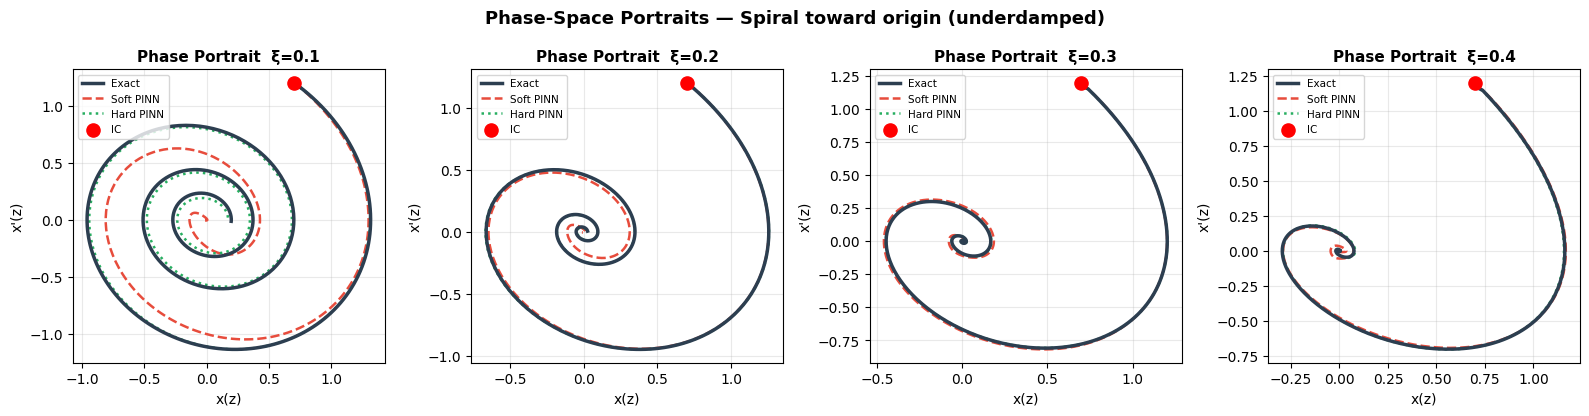

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))

for ax, xi in zip(axes, XI_EVAL):
    sr = soft_res[xi]
    hr = hard_res[xi]
    dz = sr["z"][1] - sr["z"][0]

    v_exact = np.gradient(sr["exact"], dz)
    v_soft  = np.gradient(sr["pred"],  dz)
    v_hard  = np.gradient(hr["pred"],  dz)

    ax.plot(sr["exact"], v_exact, color=C_EXACT, lw=2.5, label="Exact",    zorder=4)
    ax.plot(sr["pred"],  v_soft,  color=C_SOFT,  lw=1.8, linestyle="--",
            label="Soft PINN", zorder=3)
    ax.plot(hr["pred"],  v_hard,  color=C_HARD,  lw=1.8, linestyle=":",
            label="Hard PINN", zorder=3)
    ax.scatter([X0], [V0], color="red", s=90, zorder=6, label="IC")

    ax.set_xlabel("x(z)",  fontsize=10)
    ax.set_ylabel("x'(z)", fontsize=10)
    ax.set_title(f"Phase Portrait  ξ={xi}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.28)

fig.suptitle("Phase-Space Portraits — Spiral toward origin (underdamped)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("phase_portraits.png", dpi=150, bbox_inches="tight")
plt.show()
files.download('phase_portraits.png')


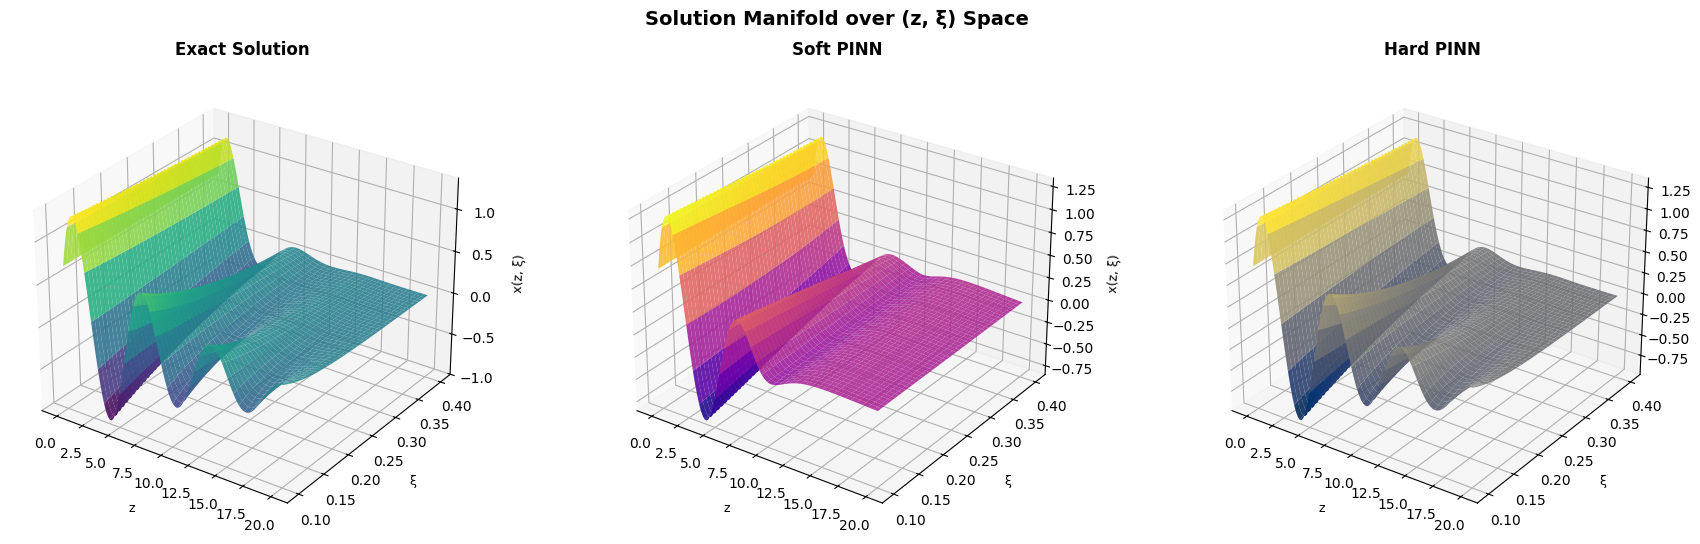

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
xi_grid = np.linspace(XI_MIN, XI_MAX, 45)
z_grid  = np.linspace(0.0, Z_MAX, 120)
ZZ, XI  = np.meshgrid(z_grid, xi_grid)

# exact
X_exact_3d = np.array([[exact_solution(z, xi) for z in z_grid]
                        for xi in xi_grid])

# PINN predictions on flattened grid
z_flat  = torch.tensor(ZZ.ravel(), dtype=torch.float32).unsqueeze(1).to(device)
xi_flat = torch.tensor(XI.ravel(), dtype=torch.float32).unsqueeze(1).to(device)

with torch.no_grad():
    X_soft_3d = soft_model(z_flat, xi_flat).cpu().numpy().reshape(ZZ.shape)
    X_hard_3d = hard_model(z_flat, xi_flat).cpu().numpy().reshape(ZZ.shape)

fig = plt.figure(figsize=(18, 5.5))
specs = [
    (X_exact_3d, "Exact Solution",  "viridis"),
    (X_soft_3d,  "Soft PINN",       "plasma"),
    (X_hard_3d,  "Hard PINN",       "cividis"),
]
for k, (surf, ttl, cmap) in enumerate(specs):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    ax.plot_surface(ZZ, XI, surf, cmap=cmap, alpha=0.88, linewidth=0,
                    antialiased=True)
    ax.set_xlabel("z",         fontsize=9,  labelpad=7)
    ax.set_ylabel("ξ",         fontsize=9,  labelpad=7)
    ax.set_zlabel("x(z, ξ)",   fontsize=9,  labelpad=7)
    ax.set_title(ttl,          fontsize=12, fontweight="bold", pad=10)
    ax.view_init(elev=28, azim=-55)

fig.suptitle("Solution Manifold over (z, ξ) Space", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("3d_solution_manifold.png", dpi=150, bbox_inches="tight")
plt.show()
files.download('3d_solution_manifold.png')

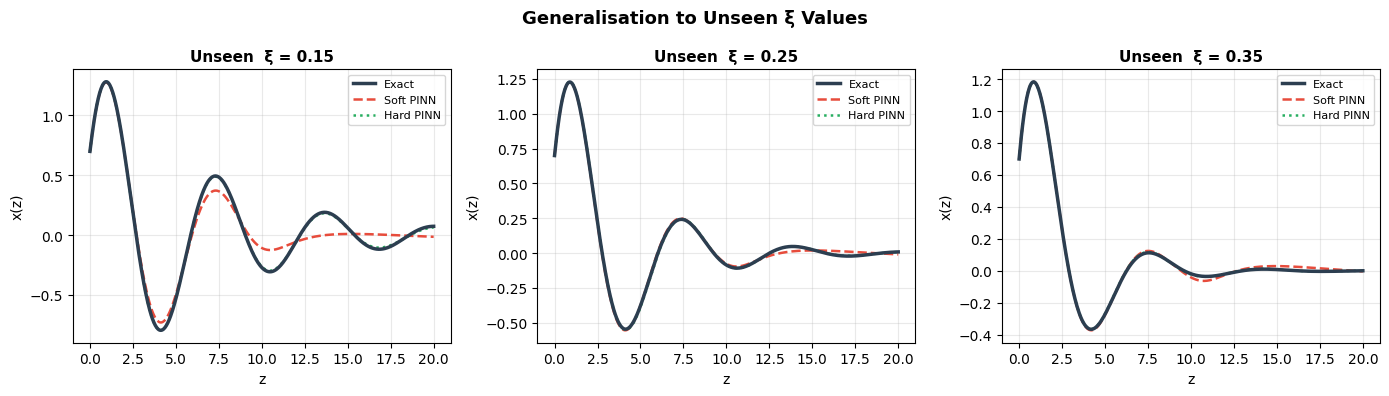

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# Check at xi values that were NEVER in the training batch (interpolation)
xi_interp = [0.15, 0.25, 0.35]
z_np_int  = np.linspace(0, Z_MAX, 500)
z_t_int   = torch.tensor(z_np_int, dtype=torch.float32).unsqueeze(1).to(device)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, xi in zip(axes, xi_interp):
    xi_t   = torch.full((500, 1), xi, device=device)
    with torch.no_grad():
        x_s = soft_model(z_t_int, xi_t).cpu().numpy().ravel()
        x_h = hard_model(z_t_int, xi_t).cpu().numpy().ravel()
    x_ref  = exact_solution(z_np_int, xi)

    ax.plot(z_np_int, x_ref, color=C_EXACT, lw=2.5, label="Exact",    zorder=4)
    ax.plot(z_np_int, x_s,  color=C_SOFT,  lw=1.8, linestyle="--",
            label="Soft PINN")
    ax.plot(z_np_int, x_h,  color=C_HARD,  lw=1.8, linestyle=":",
            label="Hard PINN")
    ax.set_title(f"Unseen  ξ = {xi}", fontsize=11, fontweight="bold")
    ax.set_xlabel("z"); ax.set_ylabel("x(z)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.28)

fig.suptitle("Generalisation to Unseen ξ Values", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("generalisation_check.png", dpi=150, bbox_inches="tight")
plt.show()
files.download('generalisation_check.png')


## 3 · Animated GIFs

The next two cells produce animated GIFs you can share as-is.

Building training-evolution GIF
    training_evolution.gif


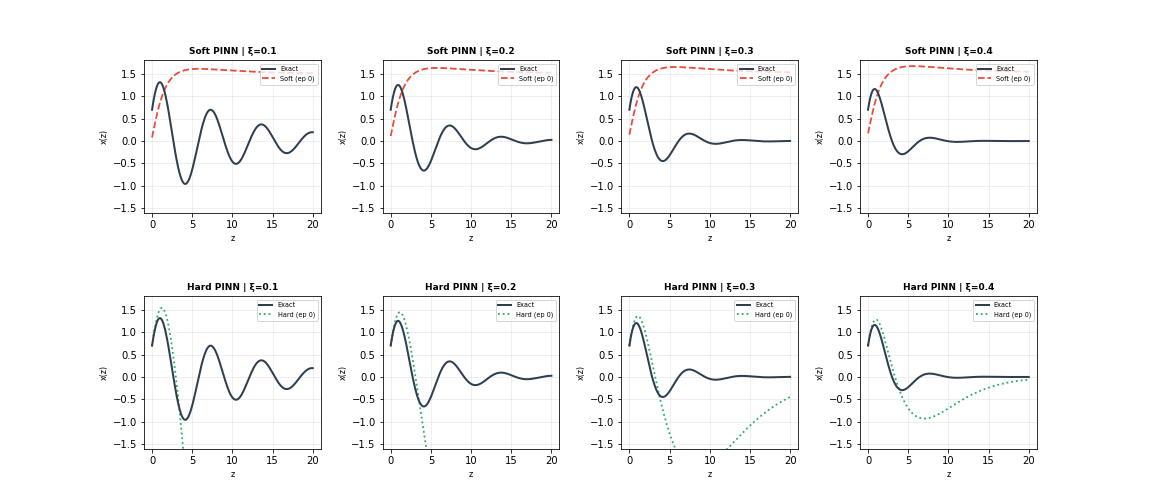

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
# GIF 1 : Solution evolution during training
print("Building training-evolution GIF")
z_gif = np.linspace(0, Z_MAX, 300)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
plt.subplots_adjust(hspace=0.55, wspace=0.35)

snap_epochs = sorted(soft_snaps.keys())          # epochs common to both

def make_frame(fi):
    ep = snap_epochs[fi]
    for col, xi in enumerate(XI_EVAL):
        xref = exact_solution(z_gif, xi)
        for row, (snaps, color, ls, lbl) in enumerate([
            (soft_snaps, C_SOFT, "--", "Soft"),
            (hard_snaps, C_HARD, ":",  "Hard"),
        ]):
            ax = axes[row, col]
            ax.clear()
            ax.plot(z_gif, xref, color=C_EXACT, lw=2, label="Exact", zorder=3)
            if ep in snaps:
                ax.plot(z_gif, snaps[ep][xi], color=color,
                        lw=1.8, linestyle=ls, label=f"{lbl} (ep {ep})")
            ax.set_ylim(-1.6, 1.8)
            ax.set_title(f"{lbl} PINN | ξ={xi}", fontsize=9, fontweight="bold")
            ax.legend(fontsize=6.5, loc="upper right")
            ax.grid(True, alpha=0.25)
            ax.set_xlabel("z", fontsize=8)
            ax.set_ylabel("x(z)", fontsize=8)

ani = animation.FuncAnimation(
    fig, make_frame, frames=len(snap_epochs), interval=160, blit=False
)
ani.save("training_evolution.gif", writer="pillow", fps=7, dpi=72)
plt.close()
print("    training_evolution.gif")
display(Image("training_evolution.gif"))
files.download('training_evolution.gif')

Building loss-convergence GIF …
 loss_convergence.gif


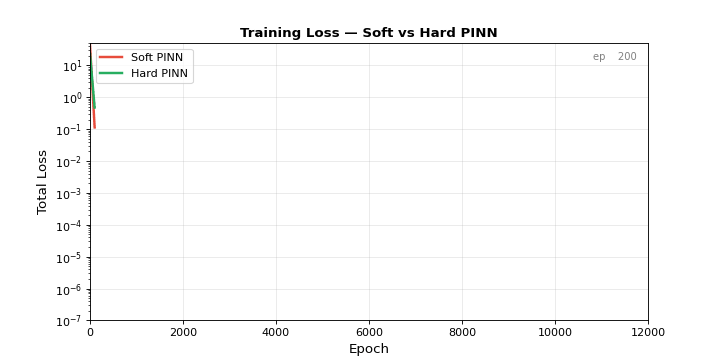

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# GIF 2 : Loss convergence
print("Building loss-convergence GIF …")
fig2, ax2 = plt.subplots(figsize=(9, 4.5))

total_frames = 60
s_ep = np.array(soft_history["epoch"])
h_ep = np.array(hard_history["epoch"])

def make_loss_frame(fi):
    ax2.clear()
    frac  = (fi + 1) / total_frames
    n_s   = max(2, int(frac * len(s_ep)))
    n_h   = max(2, int(frac * len(h_ep)))

    ax2.semilogy(s_ep[:n_s], soft_history["total"][:n_s],
                 color=C_SOFT, lw=2.2, label="Soft PINN")
    ax2.semilogy(h_ep[:n_h], hard_history["total"][:n_h],
                 color=C_HARD, lw=2.2, label="Hard PINN")
    ax2.set_xlim(0, N_EPOCHS)
    ax2.set_ylim(1e-7, 5e1)
    ax2.set_xlabel("Epoch",      fontsize=12)
    ax2.set_ylabel("Total Loss", fontsize=12)
    ax2.set_title("Training Loss — Soft vs Hard PINN", fontsize=12,
                  fontweight="bold")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.28)
    ax2.text(0.98, 0.97, f"ep {int(frac*N_EPOCHS):>6d}",
             transform=ax2.transAxes, ha="right", va="top",
             fontsize=9, color="grey")

loss_ani = animation.FuncAnimation(
    fig2, make_loss_frame, frames=total_frames, interval=120, blit=False
)
loss_ani.save("loss_convergence.gif", writer="pillow", fps=10, dpi=80)
plt.close()
print(" loss_convergence.gif")
display(Image("loss_convergence.gif"))
files.download('loss_convergence.gif')


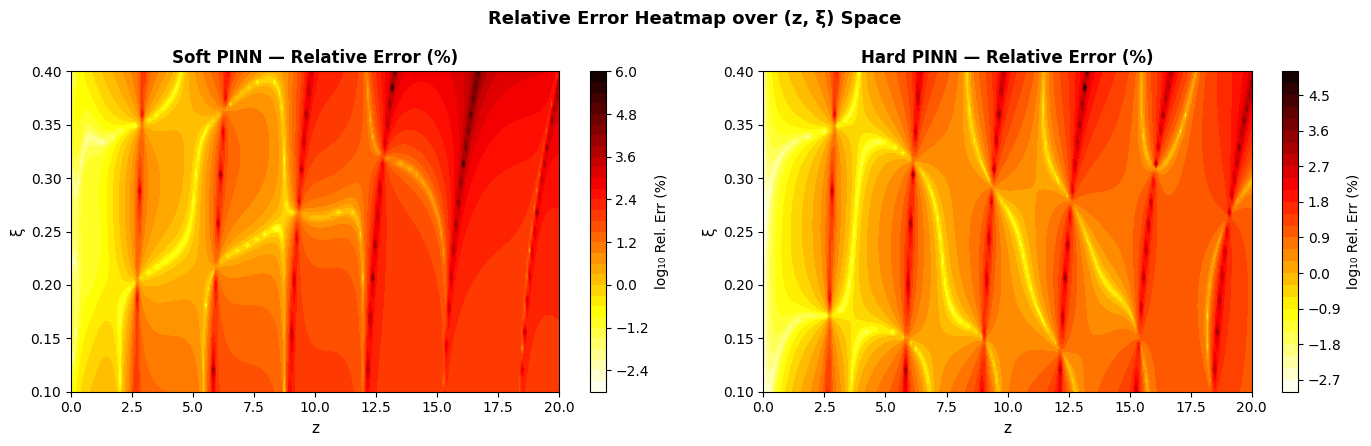

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
#  Relative-error heatmap over (z, xi) space
xi_heat = np.linspace(XI_MIN, XI_MAX, 60)
z_heat  = np.linspace(0, Z_MAX, 200)
ZH, XIH = np.meshgrid(z_heat, xi_heat)

z_hf  = torch.tensor(ZH.ravel(), dtype=torch.float32).unsqueeze(1).to(device)
xi_hf = torch.tensor(XIH.ravel(), dtype=torch.float32).unsqueeze(1).to(device)

x_ref_h = np.array([exact_solution(z_heat, xi) for xi in xi_heat])

with torch.no_grad():
    x_soft_h = soft_model(z_hf, xi_hf).cpu().numpy().reshape(ZH.shape)
    x_hard_h = hard_model(z_hf, xi_hf).cpu().numpy().reshape(ZH.shape)

err_soft_h = np.abs(x_soft_h - x_ref_h) / (np.abs(x_ref_h) + 1e-8) * 100
err_hard_h = np.abs(x_hard_h - x_ref_h) / (np.abs(x_ref_h) + 1e-8) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, err, ttl in zip(axes,
                         [err_soft_h, err_hard_h],
                         ["Soft PINN — Relative Error (%)", "Hard PINN — Relative Error (%)"]):
    im = ax.contourf(ZH, XIH, np.log10(err + 1e-3),
                     levels=30, cmap="hot_r")
    fig.colorbar(im, ax=ax, label="log₁₀ Rel. Err (%)")
    ax.set_xlabel("z",  fontsize=11)
    ax.set_ylabel("ξ",  fontsize=11)
    ax.set_title(ttl,   fontsize=12, fontweight="bold")

fig.suptitle("Relative Error Heatmap over (z, ξ) Space", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.savefig("error_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
files.download('error_heatmap.png')

## 4. Discussion

### 4.1 What Worked Well
* **Successfully Learning the Solution Manifold:** Both networks generalized to learn the continuous solution manifold across the damping ratio range $\xi \in [0.1, 0.4]$, accurately predicting decay and frequency rather than overfitting to a single trajectory.
* **Exact IC Enforcement (Hard PINN):** Embedding the fixed initial conditions into the mathematical ansatz mathematically guaranteed an exact zero error at $z=0$, eliminating boundary constraints from the optimization problem entirely.
* **Smoother Training Dynamics:** By removing the initial condition penalty from the loss function, the Hard PINN avoided "gradient competition" between the ODE residual and boundary conditions, leading to a much smoother optimization process.

<br>

### 4.2 Where Things Got Tricky
* **Optimization Ambiguity (Soft PINN):** Enforcing initial conditions as weighted penalties in the loss function caused training instability and oscillations, as the optimizer struggled to balance interior ODE residuals against boundary constraints.
* **Hyperparameter Sensitivity:** The Soft PINN required tuning an additional hyperparameter ($\lambda_{IC}$) to scale the boundary loss, yet only achieved approximate—never exact—satisfaction of the initial conditions.
* **Long-Time Oscillatory Propagation:** Overcoming "spectral bias" (the network's tendency to learn low-frequency functions first) to accurately capture high-frequency oscillations over an extended domain ($z=20$) without artificial damping required careful non-dimensionalization and sufficient network capacity.

In [35]:
#  Compact summary printed at the end
print("\n" + "="*65)
print("  FINAL SUMMARY")
print("="*65)

for name, res in [("Soft PINN", soft_res), ("Hard PINN", hard_res)]:
    overall_rmse = np.mean([
        np.sqrt(np.mean(res[xi]["err"]**2)) for xi in XI_EVAL
    ])
    overall_rel  = np.mean([
        np.mean(res[xi]["rel"]) for xi in XI_EVAL
    ]) * 100
    print(f"  {name:12s}  |  Mean RMSE: {overall_rmse:.3e}"
          f"  |  Mean Rel. Err: {overall_rel:.4f}%")

n_p = sum(p.numel() for p in soft_model.parameters())
print(f"\n  Shared architecture: {N_HIDDEN_LAYERS} × {N_HIDDEN_UNITS} Tanh, "
      f"{n_p:,} parameters")
print(f"  Training epochs    : {N_EPOCHS:,}")
print(f"  Collocation points : {N_COL:,} / batch")
print(f"  Domain             : z ∈ [0, {Z_MAX}],  ξ ∈ [{XI_MIN}, {XI_MAX}]")
print(f"  Device             : {device}")
print("="*65)



  FINAL SUMMARY
  Soft PINN     |  Mean RMSE: 6.627e-02  |  Mean Rel. Err: 597.6108%
  Hard PINN     |  Mean RMSE: 9.209e-03  |  Mean Rel. Err: 33.4202%

  Shared architecture: 5 × 64 Tanh, 16,897 parameters
  Training epochs    : 12,000
  Collocation points : 2,500 / batch
  Domain             : z ∈ [0, 20.0],  ξ ∈ [0.1, 0.4]
  Device             : cuda
